In [25]:
print("Hello World")

Hello World


## __Libraries and Installations__

In [28]:
import numpy as np
np.float = float
np.int = int

In [32]:
!pip install plotly ipywidgets pandas

Defaulting to user installation because normal site-packages is not writeable


In [88]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import VBox, HBox

## __Loading LIQUIAC Data__

In [72]:
base = "NaCl-DIPA/"

xE = pd.read_excel(base + "xE_exp.xlsx")
xR = pd.read_excel(base + "xR_exp.xlsx")
T  = pd.read_excel(base + "T_exp.xlsx")
z  = pd.read_excel(base + "z_exp.xlsx")

# model results (optional)
try:
    results = pd.read_csv(base + "results_liquac.csv")
except:
    results = None

## __Creating Central DataFrame__

In [78]:
df = pd.DataFrame()

df["T"] = T.iloc[:,0]

# Extract phase
df["DIPA_E"] = xE["DIPA"]
df["H2O_E"]  = xE["H2O"]

# Raffinate phase
df["DIPA_R"] = xR["DIPA"]
df["H2O_R"]  = xR["H2O"]

# NaCl via mass balance
df["NaCl_E"] = 1 - df["DIPA_E"] - df["H2O_E"]
df["NaCl_R"] = 1 - df["DIPA_R"] - df["H2O_R"]

df["point_id"] = np.arange(len(df))


# Feed compositions
z["NaCl"] = 1 - z["DIPA"] - z["H2O"]


print("Data preview:")

Data preview:


In [80]:
df.head()

,T,DIPA_E,H2O_E,DIPA_R,H2O_R,NaCl_E,NaCl_R,point_id
0,288.15,0.246162,0.737492,0.008722,0.929404,0.016346,0.061874,0
1,288.15,0.338000,0.650152,0.006725,0.914663,0.011848,0.078611,1
2,288.15,0.436355,0.555904,0.005713,0.898832,0.007741,0.095455,2
3,288.15,0.458808,0.536606,0.003780,0.885503,0.004586,0.110717,3
4,288.15,0.521247,0.476312,0.001877,0.873678,0.002440,0.124445,4


## __Ternary Plot__

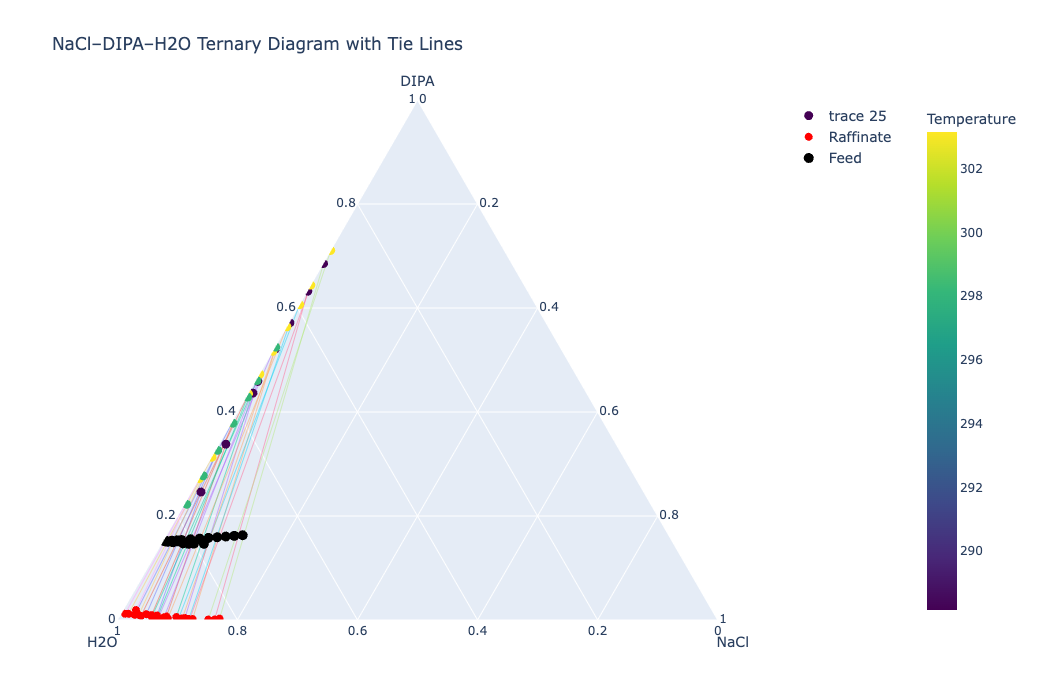

In [121]:
fig = go.Figure()

# Tie lines
for i in range(len(df)):
    fig.add_scatterternary(
        a=[df["DIPA_E"][i], df["DIPA_R"][i]],
        b=[df["H2O_E"][i], df["H2O_R"][i]],
        c=[df["NaCl_E"][i], df["NaCl_R"][i]],
        mode="lines",
        line=dict(width=1),
        opacity=0.5,
        showlegend=False
    )

# Extract
fig.add_scatterternary(
    a=df["DIPA_E"],
    b=df["H2O_E"],
    c=df["NaCl_E"],
    mode="markers",
    marker=dict(
    size=9,
    color=df["T"],
    colorscale="Viridis",
    showscale=True,
    colorbar=dict(
        title="Temperature",
        x=1.25
    )
    )
)

# Raffinate
fig.add_scatterternary(
    a=df["DIPA_R"],
    b=df["H2O_R"],
    c=df["NaCl_R"],
    mode="markers",
    marker=dict(size=8, color="red"),
    name="Raffinate"
)

# Feed
fig.add_scatterternary(
    a=z["DIPA"],
    b=z["H2O"],
    c=z["NaCl"],
    mode="markers",
    marker=dict(size=10, color="black"),
    name="Feed"
)

fig.update_layout(
    title="NaCl–DIPA–H2O Ternary Diagram with Tie Lines",
    ternary=dict(
        sum=1,
        aaxis=dict(title="DIPA"),
        baxis=dict(title="H2O"),
        caxis=dict(title="NaCl")
    ),
    legend=dict(
        x=1.05,
        y=1,
        bgcolor="rgba(0,0,0,0)",
        borderwidth=0,
        font=dict(size=14)
    ),
    width=950,
    height=700

)

fig.show()

### __Tenory Plot Extension, With Step Specific Visualization__

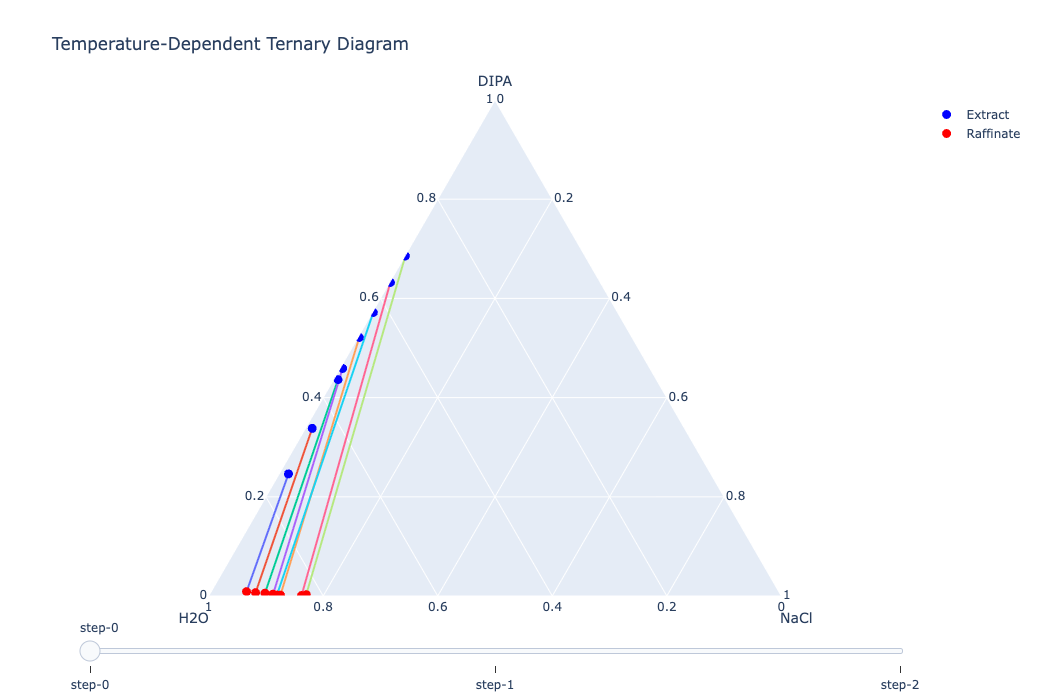

In [130]:
base = "NaCl-DIPA/"

xE = pd.read_excel(base + "xE_exp.xlsx")
xR = pd.read_excel(base + "xR_exp.xlsx")
T  = pd.read_excel(base + "T_exp.xlsx")

df = pd.DataFrame()

df["T"] = T.iloc[:,0]

df["DIPA_E"] = xE["DIPA"]
df["H2O_E"]  = xE["H2O"]
df["NaCl_E"] = 1 - df["DIPA_E"] - df["H2O_E"]

df["DIPA_R"] = xR["DIPA"]
df["H2O_R"]  = xR["H2O"]
df["NaCl_R"] = 1 - df["DIPA_R"] - df["H2O_R"]


temps = sorted(df["T"].unique())

fig = go.Figure()

# Create traces for each temperature
for Tval in temps:

    d = df[df["T"] == Tval]

    for i in range(len(d)):

        fig.add_scatterternary(
            a=[d.iloc[i]["DIPA_E"], d.iloc[i]["DIPA_R"]],
            b=[d.iloc[i]["H2O_E"],  d.iloc[i]["H2O_R"]],
            c=[d.iloc[i]["NaCl_E"], d.iloc[i]["NaCl_R"]],
            mode="lines",
            line=dict(width=2),
            visible=False,
            showlegend=False
        )

    fig.add_scatterternary(
        a=d["DIPA_E"],
        b=d["H2O_E"],
        c=d["NaCl_E"],
        mode="markers",
        marker=dict(size=9, color="blue"),
        name="Extract",
        visible=False
    )

    fig.add_scatterternary(
        a=d["DIPA_R"],
        b=d["H2O_R"],
        c=d["NaCl_R"],
        mode="markers",
        marker=dict(size=9, color="red"),
        name="Raffinate",
        visible=False
    )


# make first temperature visible
for i in range(len(fig.data)//len(temps)):
    fig.data[i].visible = True


# slider
steps = []
n_traces = len(fig.data) // len(temps)

for i,Tval in enumerate(temps):

    step = dict(
        method="update",
        args=[{"visible":[False]*len(fig.data)},
              {"title":f"Ternary Diagram at T = {Tval}"}],
    )

    for j in range(n_traces):
        step["args"][0]["visible"][i*n_traces + j] = True

    steps.append(step)

sliders = [dict(active=0, steps=steps)]

fig.update_layout(
    sliders=sliders,
    ternary=dict(
        sum=1,
        aaxis_title="DIPA",
        baxis_title="H2O",
        caxis_title="NaCl"
    ),
    title="Temperature-Dependent Ternary Diagram",
    width=900,
    height=700
)

fig.show()

## __Binary Projection Plot__

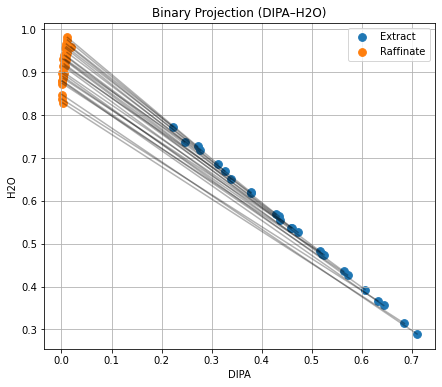

In [105]:
plt.figure(figsize=(7,6))

for i in range(len(df)):

    plt.plot(
        [df["DIPA_E"][i], df["DIPA_R"][i]],
        [df["H2O_E"][i], df["H2O_R"][i]],
        'k-',
        alpha=0.3
    )


plt.scatter(df["DIPA_E"], df["H2O_E"], label="Extract", s=60)
plt.scatter(df["DIPA_R"], df["H2O_R"], label="Raffinate", s=60)

plt.xlabel("DIPA")
plt.ylabel("H2O")

plt.title("Binary Projection (DIPA–H2O)")

plt.legend()
plt.grid()

plt.show()

## __Composition Error Map (not working yet)__

In [61]:
marker=dict(
    size=8,
    color=df["T"],
    colorscale="Viridis",
    showscale=True
)

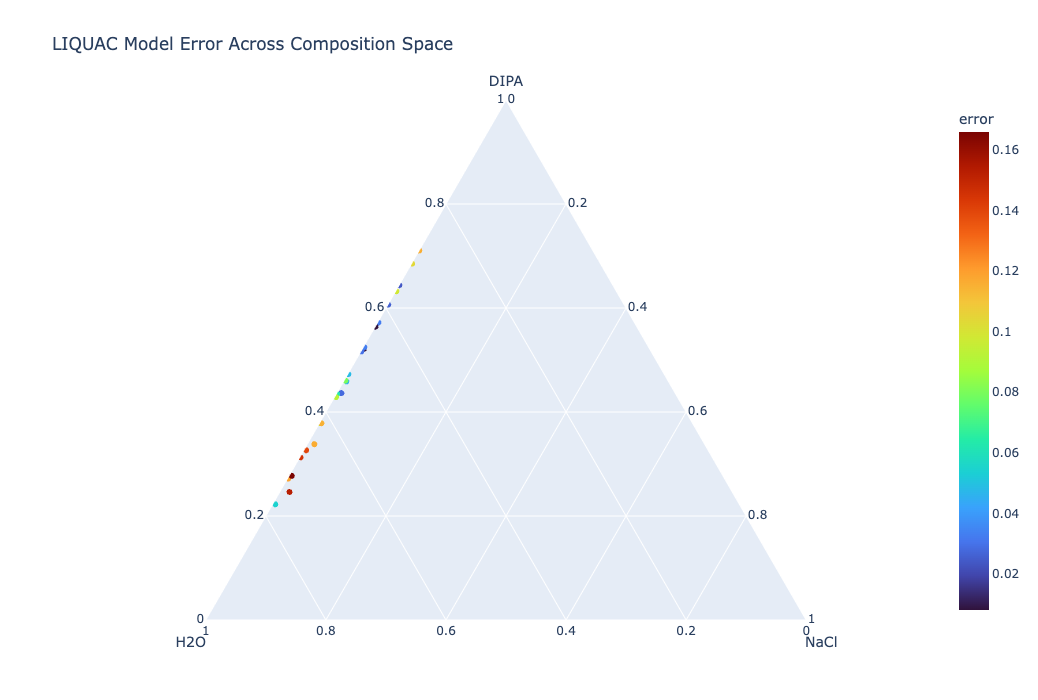

In [139]:
results = pd.read_csv("NaCl-DIPA/results_liquac.csv")

# Compute error (extract phase solvent)
results["error"] = abs(results["xE_solvent"] - results["xE_exp_solvent"])

# Build ternary coordinates
results["DIPA"] = results["xE_exp_solvent"]
results["H2O"]  = results["xE_exp_water"]
results["NaCl"] = results["xE_exp_cation"] + results["xE_exp_anion"]

fig = px.scatter_ternary(
    results,
    a="DIPA",
    b="H2O",
    c="NaCl",
    color="error",
    color_continuous_scale="Turbo",
    title="LIQUAC Model Error Across Composition Space"
)

fig.update_layout(
    ternary=dict(
        sum=1,
        aaxis_title="DIPA",
        baxis_title="H2O",
        caxis_title="NaCl"
    ),
    width=900,
    height=700
)

fig.show()

In [133]:
results = pd.read_csv("NaCl-DIPA/results_liquac.csv")

print(results.columns)
results.head()

Index(['xE_exp_solvent', 'xE_exp_water', 'xE_exp_cation', 'xE_exp_anion',
       'xR_exp_solvent', 'xR_exp_water', 'xR_exp_cation', 'xR_exp_anion',
       'xE_solvent', 'xE_water', 'xE_cation', 'xE_anion', 'xR_solvent',
       'xR_water', 'xR_cation', 'xR_anion', 'RMS_contribution'],
      dtype='object')


,xE_exp_solvent,xE_exp_water,xE_exp_cation,xE_exp_anion,xR_exp_solvent,xR_exp_water,xR_exp_cation,xR_exp_anion,xE_solvent,xE_water,xE_cation,xE_anion,xR_solvent,xR_water,xR_cation,xR_anion,RMS_contribution
0,0.246162,0.737492,0.008173,0.008173,0.008722,0.929404,0.030937,0.030937,0.399016,0.600864,0.00006,0.00006,0.006559,0.945461,0.023990,0.023990,42.522443
1,0.338000,0.650152,0.005924,0.005924,0.006725,0.914663,0.039306,0.039306,0.454448,0.545412,0.00007,0.00007,0.004272,0.928674,0.033527,0.033527,24.868481
2,0.436355,0.555904,0.003870,0.003870,0.005713,0.898832,0.047728,0.047728,0.464477,0.535423,0.00005,0.00005,0.002676,0.908968,0.044178,0.044178,1.376650
3,0.458808,0.536606,0.002293,0.002293,0.003780,0.885503,0.055359,0.055359,0.504600,0.495280,0.00006,0.00006,0.001875,0.892226,0.052950,0.052950,3.875093
4,0.521247,0.476312,0.001220,0.001220,0.001877,0.873678,0.062223,0.062223,0.529328,0.470552,0.00006,0.00006,0.001276,0.874791,0.061966,0.061966,0.102908
